### Importação das Bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Carregamento dos Dados com CSV

In [ ]:
# try: 
#     # Delimitador é vírgula e pula a primeira linha (cabeçalho) com skiprows
#     # dados = np.loadtxt('.csv', delimiter=',', skiprows=1, usecols=(2, 3)) 
# except FileNotFoundError:
#     print("Erro: arquivo 'dataset.csv' não encontrado")
#     print("Por favor, crie o arquivo ou execute o script para gerá-lo.")
#     exit()

In [ ]:
# apenas visualiza os dados carregados do arquivo CSV
# print(dados)

[[2.21900e+05 3.00000e+00]
 [5.38000e+05 3.00000e+00]
 [1.80000e+05 2.00000e+00]
 ...
 [4.02101e+05 2.00000e+00]
 [4.00000e+05 3.00000e+00]
 [3.25000e+05 2.00000e+00]]


### Separando os dados e X e Y

In [ ]:
# criando dados (já que não há dataset para usar como base)
x = np.array([0, 5, 10, 15, 20])
y = np.array([20, 40, 60, 90, 100])

# Visualiza os dados
print('X:', x)
print('Y:', y)

print("\nNúmero de amostras: ", x.shape[0])

X: [ 0  5 10 15 20]
Y: [ 20  40  60  90 100]

Número de amostras:  5


In [3]:
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

print('X:', x)
print('\nY:', y)

# Descomente a linha abaixo se quiser ver detalhes dos dados

#print('Número de características:', x.reshape[1])
#print('Número de saídas)

X: [[ 0]
 [ 5]
 [10]
 [15]
 [20]]

Y: [[ 20]
 [ 40]
 [ 60]
 [ 90]
 [100]]


### Calculando 'A' e 'B'

In [5]:
# Calcular os coeficientes da regressão linear (A e B)
x_mean = np.mean(x)
y_mean = np.mean(y)

print('Média de X:', x_mean)
print('Média de Y:', y_mean)

Média de X: 10.0
Média de Y: 62.0


In [6]:
def predict(x_novo, _m, _b):
    """
    Prevê novos valores de y com base nos coeficientes da regressão.
    Args:
        x_novo: Um número ou array NumPy com os novos valores de x.
        m: Coeficiente angular (slope) do modelo.
        b: O intercepto do modelo
    Returns: O(s) valor(es) de y previstos
    """
    return _m * x_novo + _b

Coeficientes calculados a partir do CSV: 
Coeficiente angular (m): 4.2000
Intercepto (b) 20.0000

Equação da linha: y = 4.2000x + 20.0000

Coeficiente de Determinação (R²): 0.9844
O modelo tem um bom ajuste aos dados.


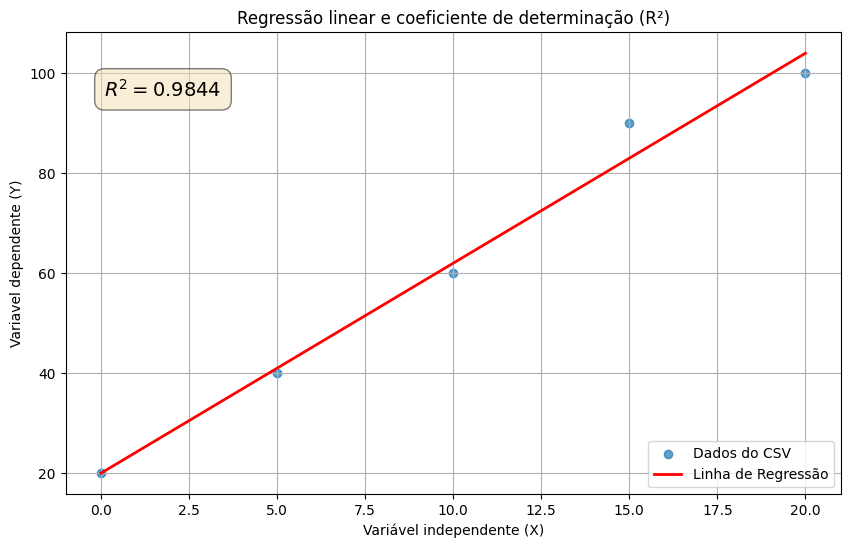

In [ ]:
m = len(x)
numerador = np.sum((x - x_mean) * (y - y_mean))
denominador = np.sum((x - x_mean) ** 2)

m = numerador / denominador
b = y_mean - (m * x_mean)

# Fazer as previsões do modelo
# Para cada valor de x, calculamos o y previsto (^y) pela nossa linha.
y_pred = m * x + b

# Calcular o R-quadrado (R²) para avaliar o modelo 
sqr = np.sum((y - y_pred) ** 2) # Soma quadrática dos resíduos
sqt = np.sum((y - y_mean) ** 2) # Soma quadrática total
r2 = 1 - (sqr / sqt)

# Imprimir os resultados
print(f"Coeficientes calculados a partir do CSV: ")
print(f"Coeficiente angular (m): {m:.4f}")
print(f"Intercepto (b) {b:.4f}")
print("\nEquação da linha: y = {:.4f}x + {:.4f}".format(m, b))
print(f"\nCoeficiente de Determinação (R²): {r2:.4f}")
if r2 > 0.75:
    print('O modelo tem um bom ajuste aos dados.')
elif r2 > 0.5:
    print('O modelo tem um ajuste moderado')
else:
    print('O modelo tem um ajuste fraco')

# Criar a linha de regressão para Visualização
x_line = np.array([x.min(), x.max()])
y_line = m * x_line + b

# Visualizar os resultados
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Dados do CSV', alpha=0.7)
plt.plot(x_line, y_line, color='red', linewidth=2, label='Linha de Regressão')

# Adiciona o valor R² ao gráfico para fácil vizualização
plt.text(0.05, 0.9, f'$R^2 = {r2:.4f}$', transform=plt.gca().transAxes,
         fontsize=14, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

plt.title("Regressão linear e coeficiente de determinação (R²)")
plt.xlabel('Variável independente (X)')
plt.ylabel('Variavel dependente (Y)')
plt.legend()
plt.grid(True)
plt.show()

a) O modelo de regressão linear conseguiu representar bem a relação entre
investimento em marketing e faturamento? Justifique observando o gráfico.
- **Sim.** Pelo gráfico, os pontos observados estão muito próximos da reta de regressão. Além disso, o coeficiente de determinação obtido foi R² = 0,9844, indicando que aproximadamente 98,44% da variação do faturamento é explicada pelo investimento em marketing.

b) Qual é o coeficiente angular (inclinação da reta) e como ele pode ser
interpretado no contexto do problema?
- **Coeficiente angular (m): 4,2000.**
- **Interpretação:** Para cada R$ 1 mil adicional investido em marketing, o faturamento estimado da empresa aumenta em R$ 4,20 mil.

c) Se a empresa investir R$ 15 mil em marketing, qual seria o faturamento previsto
pelo modelo?
- **Cálculo:** y = 4,2000 * 15 + 20,0000 = 63,00 + 20,00 = 83,00.
- **Resposta:** O faturamento previsto é de **R$ 83 mil**.

d) Existem indícios de que o crescimento do faturamento pode ser limitado (isto é,
que a relação pode não ser linear para investimentos muito altos)?
- **Sim.** Observando os pontos finais (x = 15 para y = 90, e x = 20 para y = 100), nota-se uma desaceleração no ritmo de crescimento (o ganho caiu para 10 unidades com mais 5 de investimento). Isso sugere saturação de mercado e a lei dos rendimentos decrescentes, indicando que em faixas muito altas a relação tende a se tornar não linear.

e) Você considera que apenas o marketing explica o faturamento da empresa ou
outros fatores deveriam ser incluídos em um modelo mais realista?
- **Não.** Apenas o marketing não é suficiente. Em um cenário real, fatores como sazonalidade, concorrência, qualidade e preço do produto, tamanho do mercado e eficiência da equipe de vendas também influenciam diretamente o faturamento. Um modelo mais realista utilizaria regressão múltipla incluindo essas variáveis.